# Two-Site Binding Model with Cooperativity

This notebook simulates surface response traces for a ligand **P** with two equivalent binding sites whose **second binding event is modulated by cooperativity**.

The analyte **L** binds sequentially:

- P + L ⇌ PL  (singly bound)
- PL + L ⇌ LPL  (doubly bound)

A cooperativity factor `sigma` modifies the second binding step:

- `sigma > 1`: positive cooperativity
- `sigma = 1`: non-cooperative limit
- `sigma < 1`: negative cooperativity

Both bound states contribute to the measured signal through `Rmax_PL` and `Rmax_LPL`.

In [12]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_two_site_cooperative_association,
    solve_two_site_cooperative_dissociation,
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `kon`: intrinsic association rate constant per site $(1/\mu M/s)$
- `koff`: intrinsic dissociation rate constant per site $(1/s)$
- `sigma`: cooperativity factor for the second binding event
- `Rmax_PL`: signal contribution of the singly bound complex
- `Rmax_LPL`: signal contribution of the doubly bound complex

In this implementation:

- on-rate for the second step $= \sqrt{\sigma}\,k_{on}$
- off-rate for the second step $= k_{off}/\sqrt{\sigma}$

In [13]:
kon = 0.5
koff = 0.01
sigma = 3.0  # >1 positive cooperativity, <1 negative cooperativity

Rmax_PL = 0.5
Rmax_LPL = 1.0

In [14]:
concentrations = np.logspace(-2, 1, 6)  # In μM
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [15]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:
    assoc_matrix = solve_two_site_cooperative_association(
        time=t_assoc,
        a_conc=conc,
        kon=kon,
        koff=koff,
        sigma=sigma,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=0,
        fLPL_0=0,
    )

    y_assoc = assoc_matrix[:, 0]
    fPL_end = assoc_matrix[-1, 1] / Rmax_PL if Rmax_PL else 0
    fLPL_end = assoc_matrix[-1, 2] / Rmax_LPL if Rmax_LPL else 0

    disso_matrix = solve_two_site_cooperative_dissociation(
        time=t_disso,
        koff=koff,
        sigma=sigma,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=fPL_end,
        fLPL_0=fLPL_end,
    )

    y_disso = disso_matrix[:, 0]
    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} μM")

show = [True] * len(concentrations)

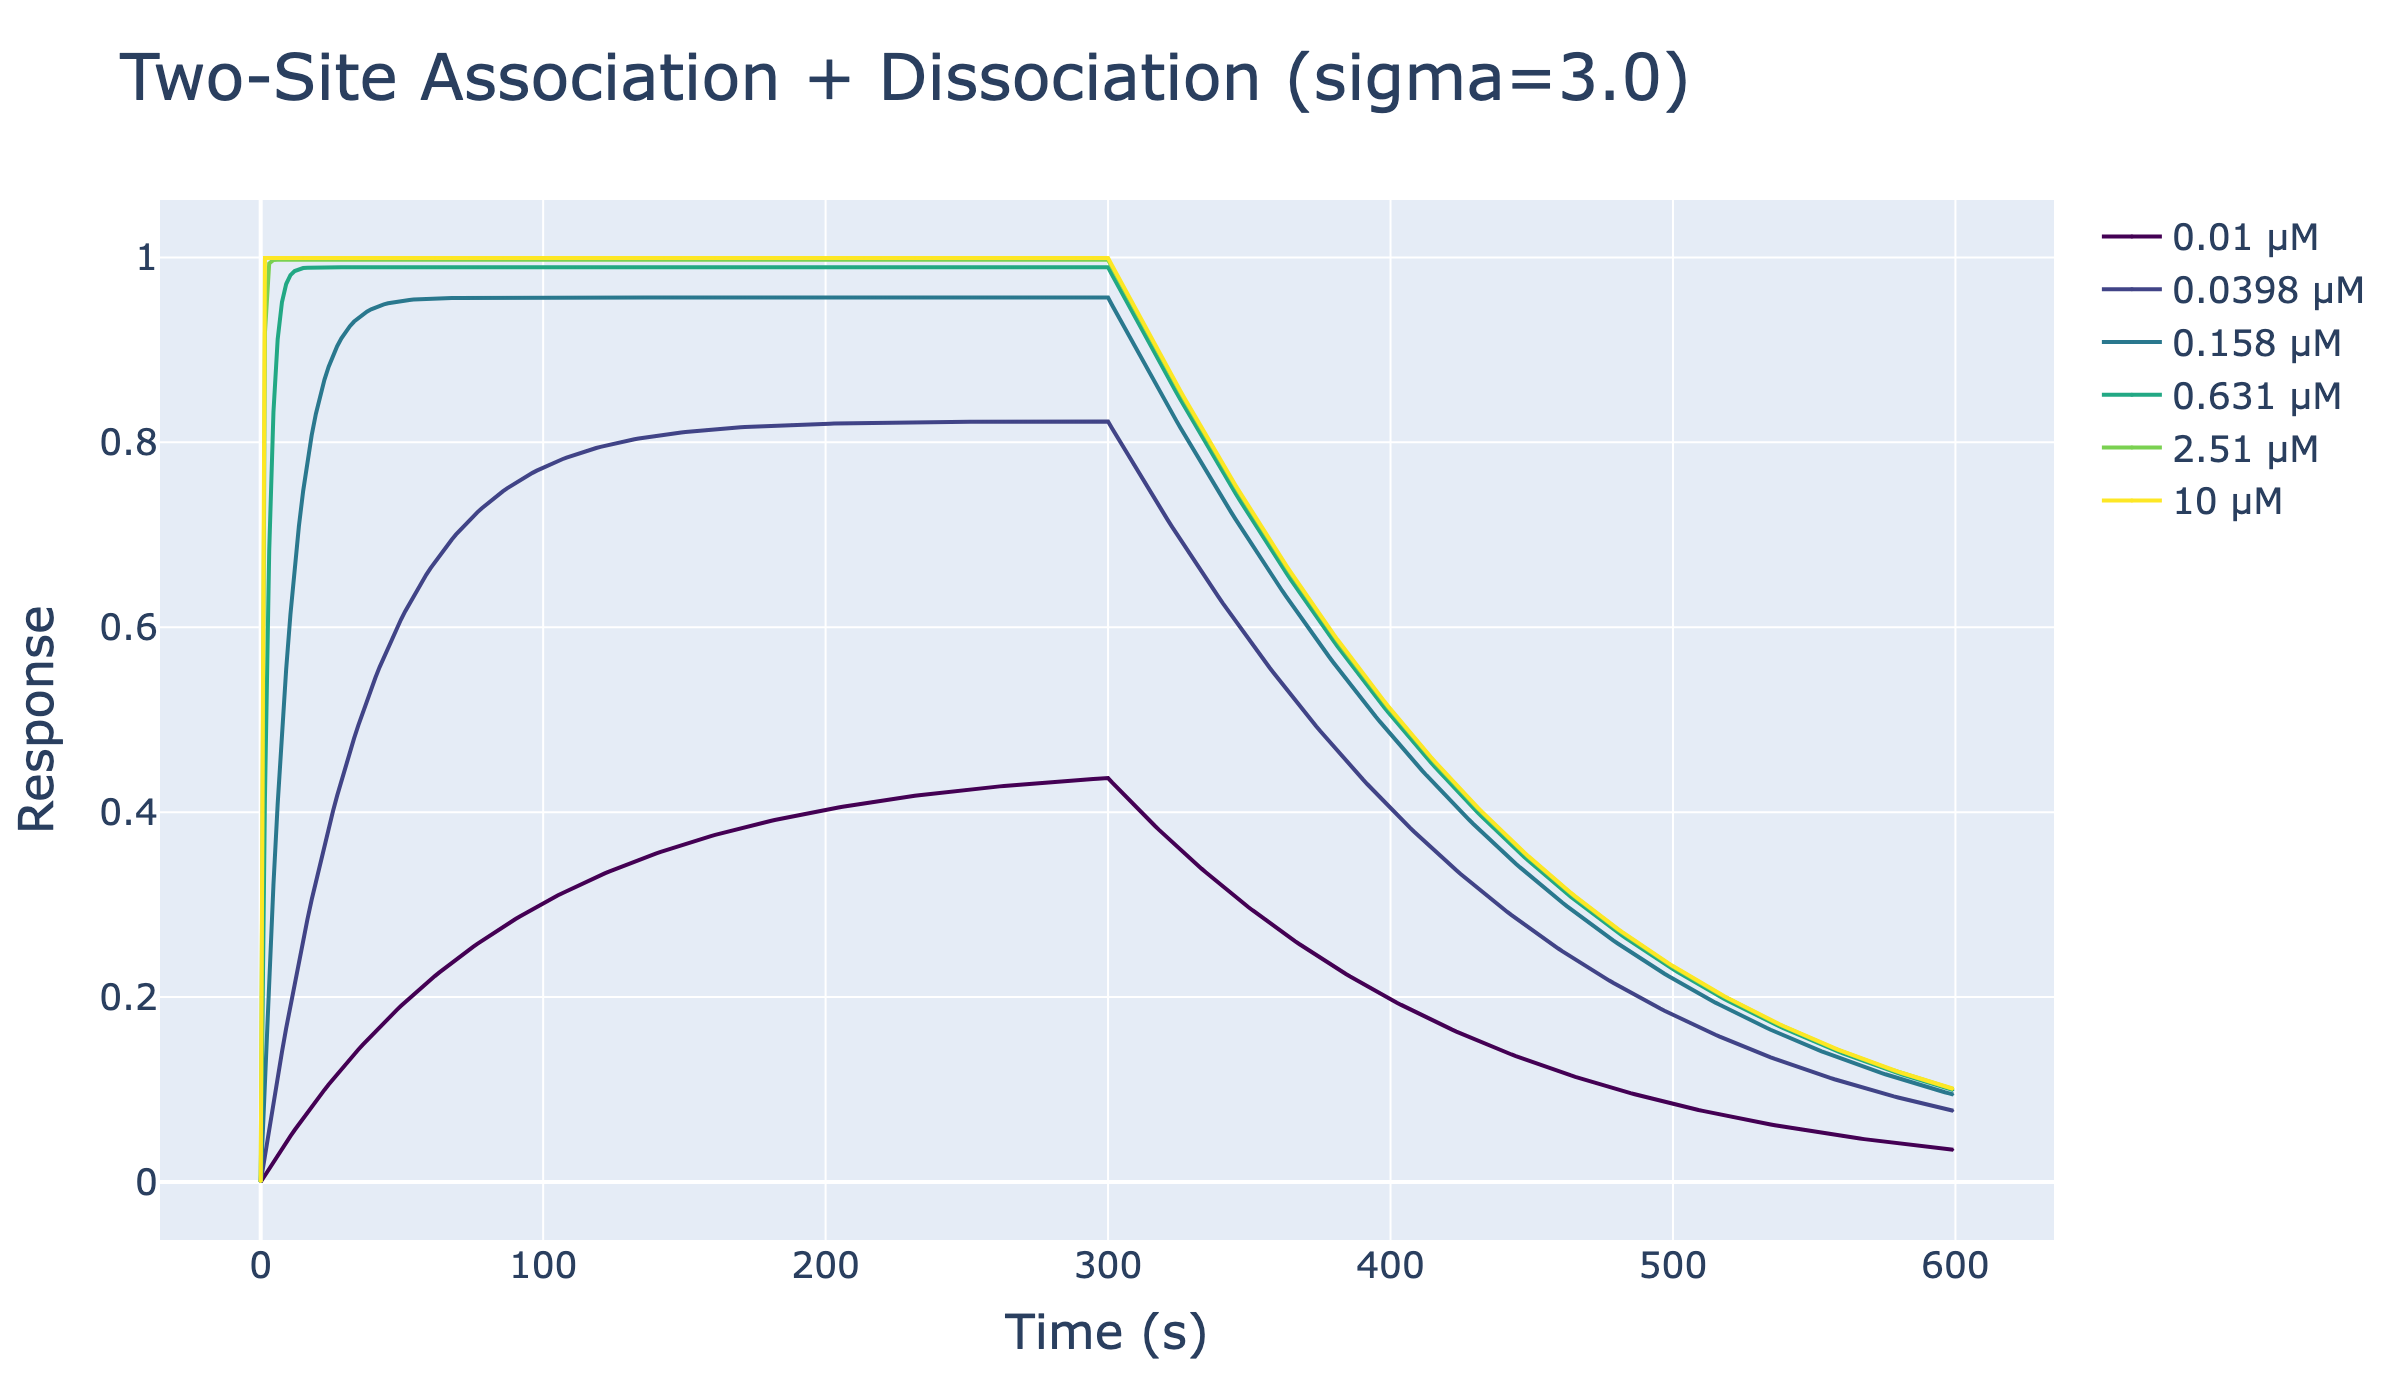

In [16]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": f"Two-Site Association + Dissociation (sigma={sigma})", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)

## Negative cooperativity example

Here we compare three regimes at the same analyte concentration:

- `sigma = 0.3`: negative cooperativity
- `sigma = 1.0`: non-cooperative reference
- `sigma = 3.0`: positive cooperativity

When `sigma < 1`, the second binding event is less favorable, so the doubly bound state accumulates less strongly and the total response is reduced.

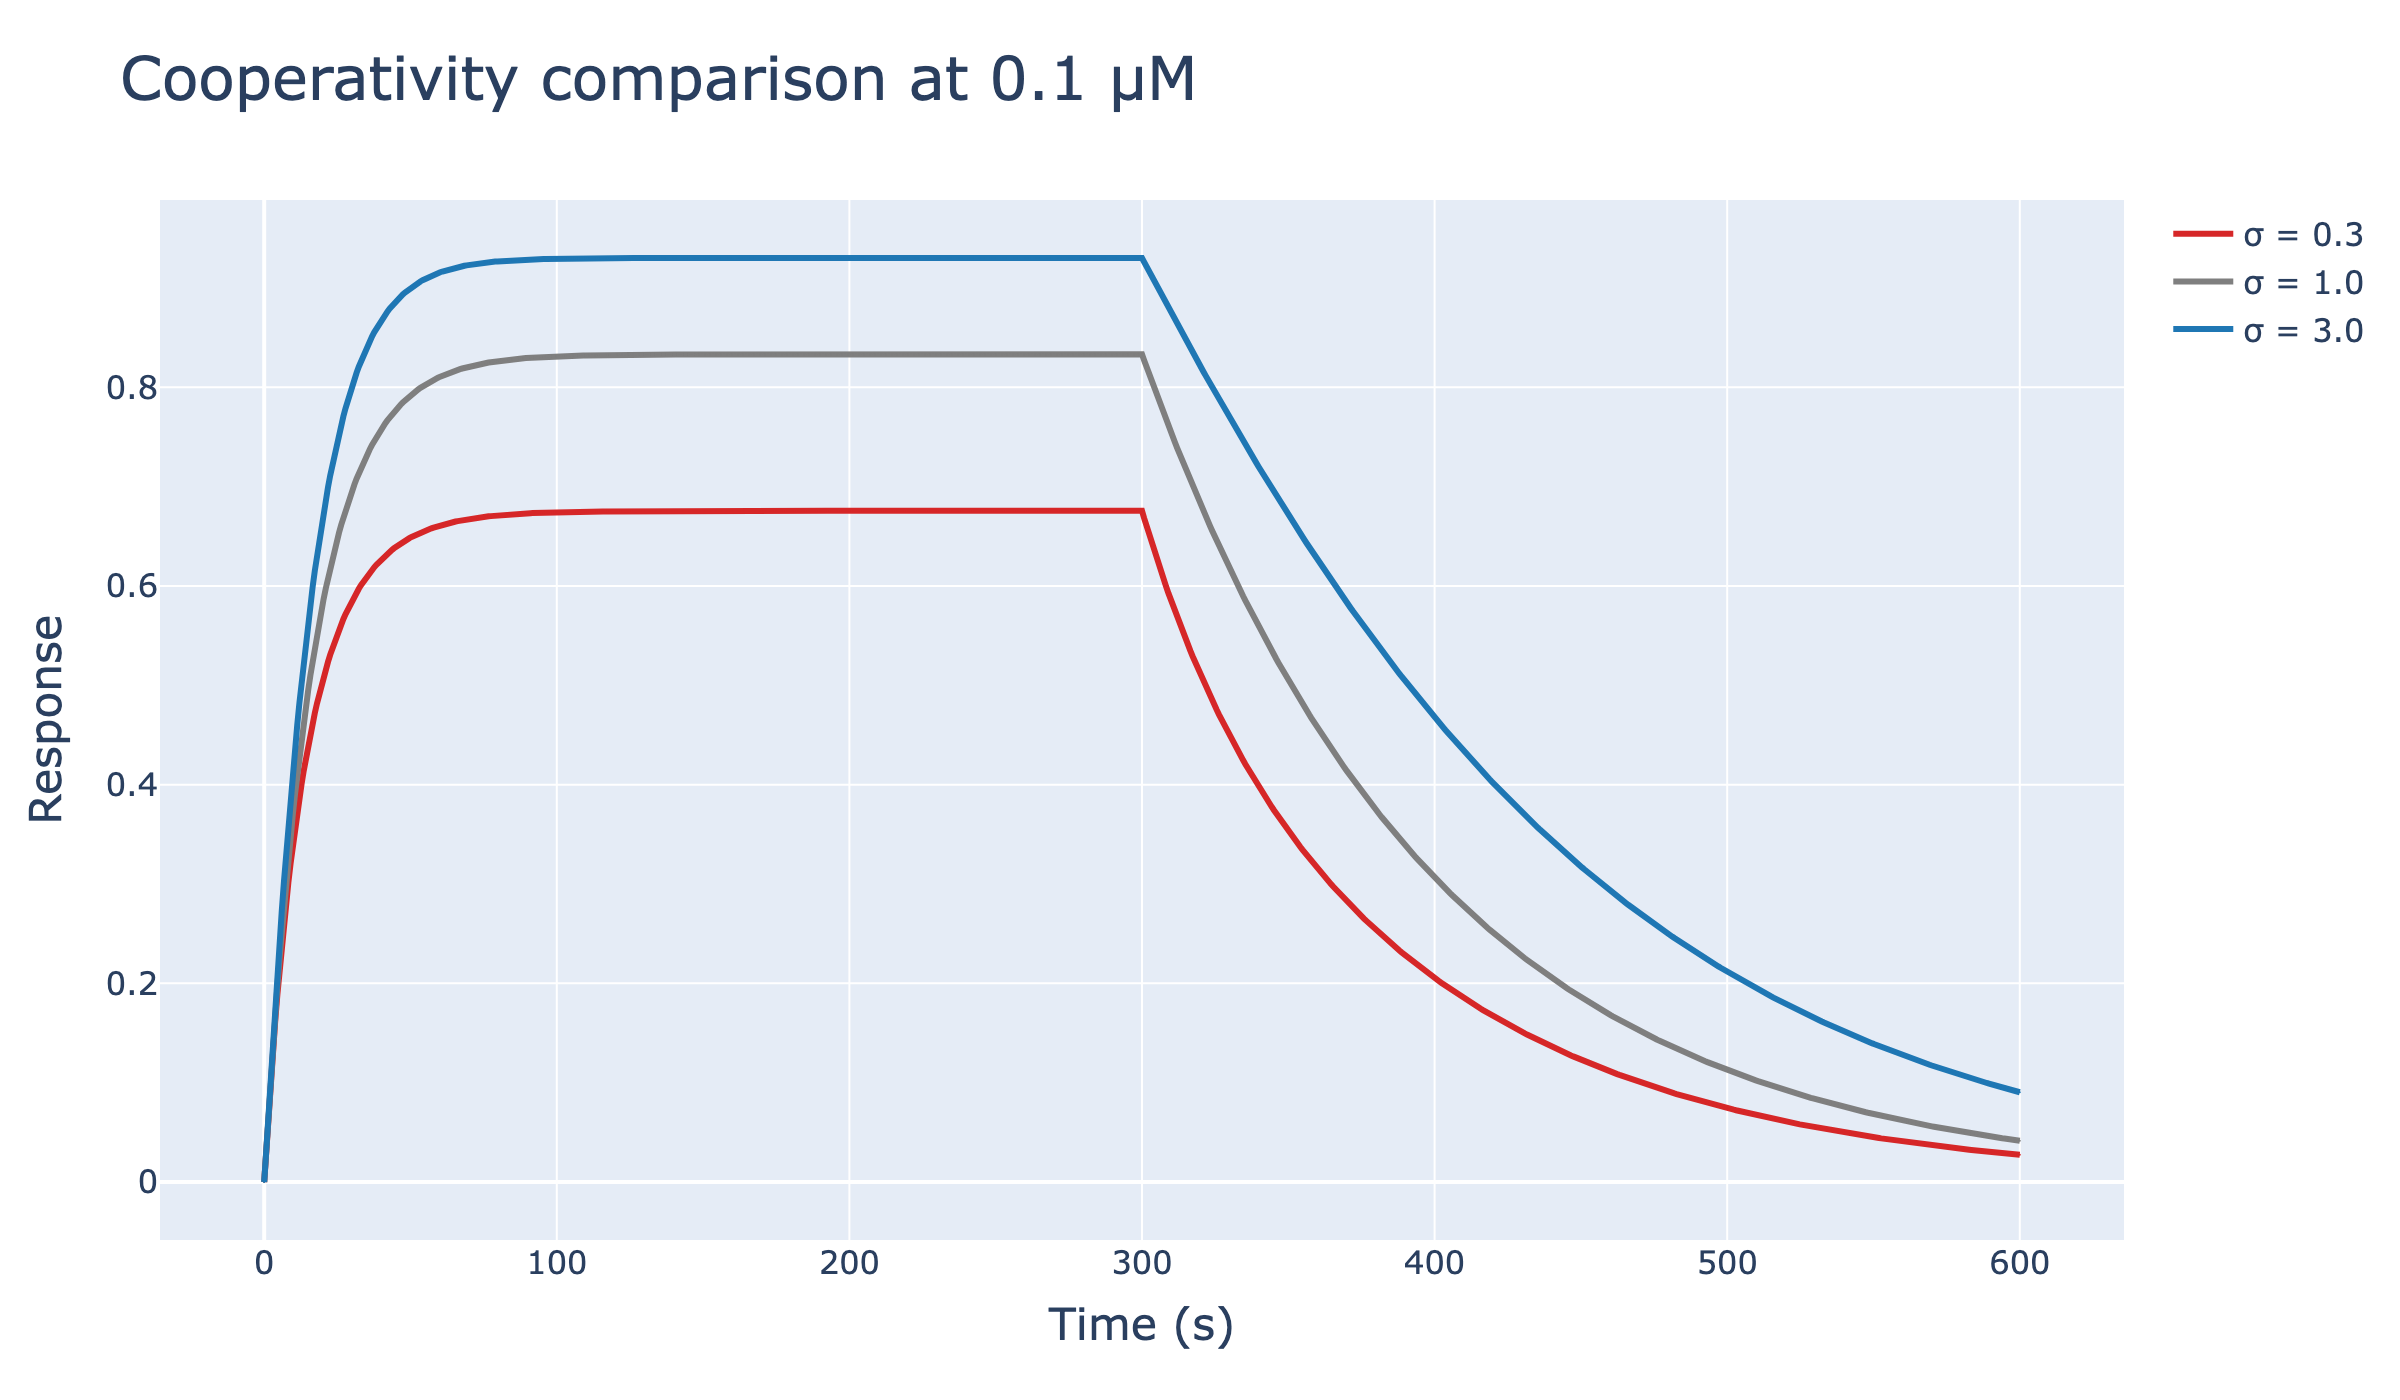

In [18]:
sigma_values = [0.3, 1.0, 3.0]
comparison_colors = ["#d62728", "#7f7f7f", "#1f77b4"]
comparison_conc = 0.1  # μM

xs_cmp, ys_cmp, legends_cmp = [], [], []

for sigma_cmp in sigma_values:
    assoc_cmp = solve_two_site_cooperative_association(
        time=t_assoc,
        a_conc=comparison_conc,
        kon=kon,
        koff=koff,
        sigma=sigma_cmp,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=0,
        fLPL_0=0,
    )

    fPL_cmp = assoc_cmp[-1, 1] / Rmax_PL if Rmax_PL else 0
    fLPL_cmp = assoc_cmp[-1, 2] / Rmax_LPL if Rmax_LPL else 0

    disso_cmp = solve_two_site_cooperative_dissociation(
        time=t_disso,
        koff=koff,
        sigma=sigma_cmp,
        Rmax_PL=Rmax_PL,
        Rmax_LPL=Rmax_LPL,
        fPL_0=fPL_cmp,
        fLPL_0=fLPL_cmp,
    )

    xs_cmp.append([t_assoc, t_disso + t_assoc[-1]])
    ys_cmp.append([assoc_cmp[:, 0], disso_cmp[:, 0]])
    legends_cmp.append(f"σ = {sigma_cmp}")

fig_cmp = plot_traces(
    xs=xs_cmp,
    ys=ys_cmp,
    legends=legends_cmp,
    colors=comparison_colors,
    show=[True] * len(sigma_values),
    marker_size=1,
    line_width=3,
)

fig_cmp.update_layout(
    title={"text": f"Cooperativity comparison at {comparison_conc} μM", "font": {"size": 30}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 18},
    legend={"font": {"size": 16}},
)
fig_cmp.update_xaxes(title_font={"size": 22}, tickfont={"size": 16})
fig_cmp.update_yaxes(title_font={"size": 22}, tickfont={"size": 16})

show_plotly_static(fig_cmp)